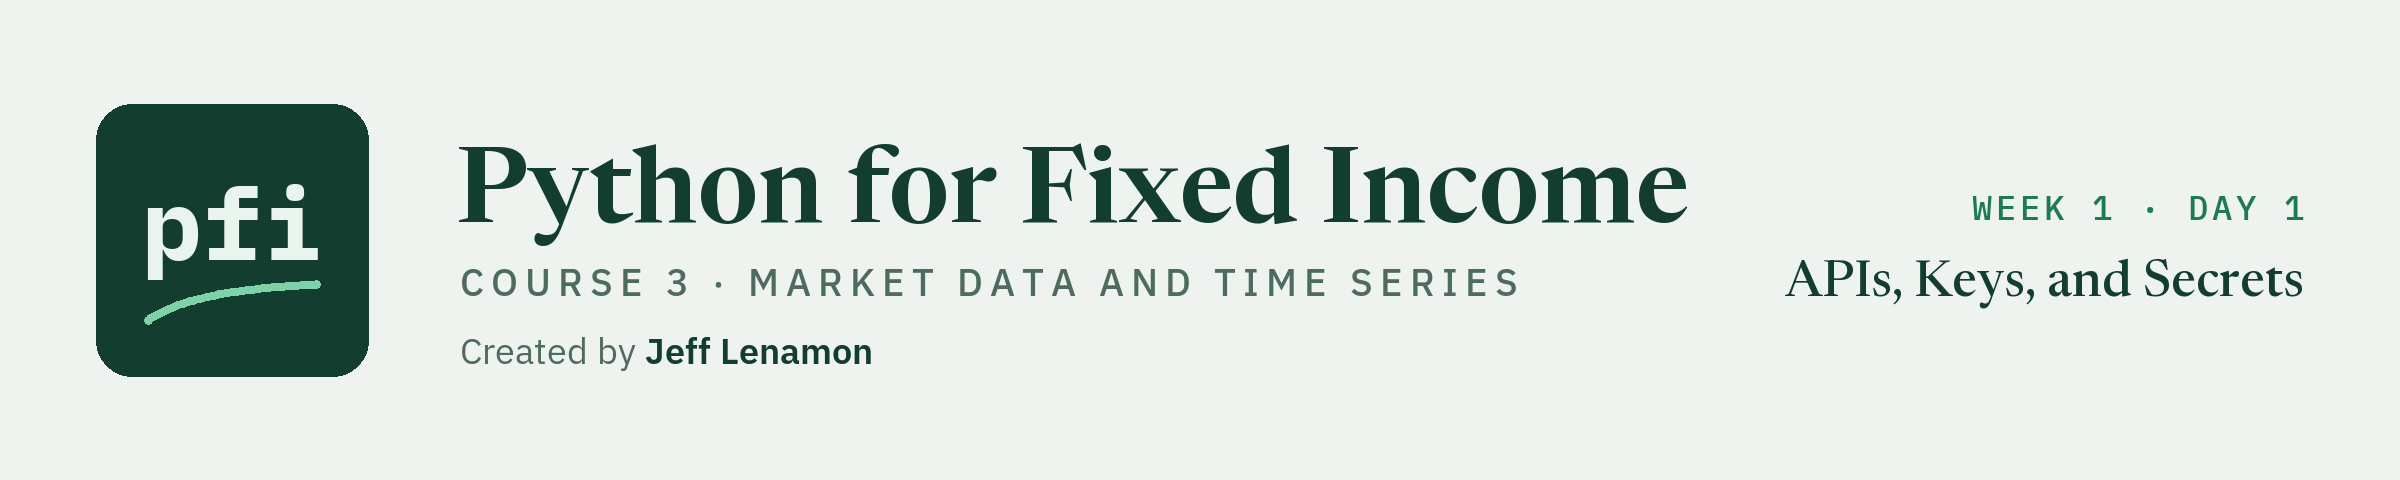

# APIs, Keys, and Secrets

Week 1, Day 1. Course 3 pulls market data from an API, and an API needs a key. Today: what an API request is, how to get a free FRED key, how to keep it out of your code, your notebooks, and Git, and your first live pull, checked against the Treasury file.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course3_market_data/week1/day1/01_apis_keys_and_secrets.ipynb)

Courses 1 and 2 read every number from files in the course repo. Course 3 adds the other way data reaches a desk: you **ask a server for it**, and the server answers. The server here is FRED, the Federal Reserve Bank of St. Louis's free economic data service, and its interface for programs, the **FRED API**.

FRED wants to know who is asking, so every request carries an **API key**: a 32-character code that belongs to you. That key is the first secret this course handles, and the rules for it are the same ones you would follow for any password: it never goes into code, a notebook, a saved output, a slide, a video, or a commit.

Today you will:

1. See the four parts of an API request: a URL, parameters, a status code, and a body.
2. Get a free FRED key, and see why it is a password.
3. Keep a secret in an environment variable, and in a `.env` file that Git never sees.
4. Write `get_secret`, the first function of your new module `marketdata.py`, docstring first, with four tests.
5. Use Colab's Secrets panel, run the key cell, and make your first live pull.
6. Put your real key in place on your own machine, and learn what to do when a key leaks.

Every demo uses the course's **fake key**, `fakefakefakefakefakefakefakefake`: 32 lowercase letters, the shape FRED expects, and obviously not a key. It is used under the name `DEMO_API_KEY`, never under `FRED_API_KEY`.

**No key yet? Run everything anyway.** Every cell runs without a key. The two live cells print a short skip message instead of live data, and the saved outputs you see are exactly that run.

The setup cell is like Course 2's, with three additions for this course: it checks that `requests` and `python-dotenv` are installed, it fixes where your key file lives (`ENV_FILE`), and it defines the skip message the live cells print when there is no key.

Q. Set up today's work folder and copy today's two data files into it.

In [1]:
# today's setup: modules, the course data, a fresh work folder, and the constants the live cells use
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# three packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("pytest", "pytest"), ("requests", "requests"), ("dotenv", "python-dotenv")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None
import pytest
import requests

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "treasury_par_yields.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. your own key file: in your my_bondmath folder, outside every repository. Its path is never printed.
ENV_FILE = Path.home() / "projects" / "my_bondmath" / ".env"

# 3. the two constants of the live cells
NO_KEY_MESSAGE = "Live cell skipped: no FRED key was found. Every other cell runs without one."
# ICE BofA and Moody's values stay off the screen unless you set this to True, on your own machine only
SHOW_LICENSED_VALUES = False

# 4. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course3_01_"))
os.chdir(work)

# 5. copy today's data files into the work folder
DATA_FILES = ["treasury_par_yields.csv", "course3_fred_format_dgs10.json"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES) or 'none'}")
print(f"pytest {pytest.__version__}, requests {requests.__version__}")

Work folder: pfi_course3_01_t07_r_8k, in your temp folder
Data files from the data folder of the course repo: treasury_par_yields.csv, course3_fred_format_dgs10.json
pytest 9.1.1, requests 2.34.2


Q. Write `bondmath.py`, the reference copy of the module you finished in Course 2.

It is written into the work folder so that every notebook runs, in Colab too, whether or not you took Course 2. To use your own copy instead, run this line in a new cell after the next one:

```python
shutil.copy(Path.home() / "projects" / "my_bondmath" / "bondmath.py", work)
```

The saved outputs of this notebook always come from the reference copy.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


Q. Import the module.

In [3]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in each module itself, not the ones it imports
def own_functions(module):
    return [name for name, obj in vars(module).items() if callable(obj) and getattr(obj, "__module__", "") == module.__name__]

print(f"bondmath (the Course 2 reference): {len(own_functions(bondmath))} functions")

bondmath (the Course 2 reference): 25 functions


* `bondmath` is imported but not used today. From day 9 on it computes DV01s for this course.

## 1.1 What an API Is: a URL, Parameters, a Status Code, a Body

An API (application programming interface) is a door a server opens for programs. A request to a web API has four parts:

| Part | What it is | FRED's version |
| --- | --- | --- |
| URL | The address of the door | `https://api.stlouisfed.org/fred/series/observations` |
| Parameters | `name=value` pairs that say what you want | which series, your key, the format, the dates |
| Status code | A number that says how it went | 200 is success; 400 is a bad request |
| Body | The answer itself | the observations, as JSON text |

Q. Write down the course's fake key and the FRED address.

In [4]:
# the course's fake key: 32 lowercase letters, the shape of a FRED key, obviously not one
FAKE_KEY = "fakefakefakefakefakefakefakefake"
# FRED's address for the observations of one series
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"
print(f"The fake key has {len(FAKE_KEY)} characters")

The fake key has 32 characters


Q. Build the request URL for the 10-year Treasury yield, FRED series `DGS10`, from September 2026 on.

In [5]:
# the parameters: which series, whose key, which format, and from which date
params = {"series_id": "DGS10", "api_key": FAKE_KEY, "file_type": "json", "observation_start": "2026-09-01"}

# a URL is the address, then ?, then name=value pairs joined by &
request_url = FRED_URL + "?" + "&".join(f"{name}={value}" for name, value in params.items())
print(request_url)

https://api.stlouisfed.org/fred/series/observations?series_id=DGS10&api_key=fakefakefakefakefakefakefakefake&file_type=json&observation_start=2026-09-01


* The key travels **inside the URL**, as `api_key=...`. That one fact drives the rest of today: anything that prints a URL, logs it, or puts it in an error message prints your key with it. This one is safe to print because the key is fake.
* FRED's own documentation calls the key "a 32 character lower-cased alpha-numeric string" (https://fred.stlouisfed.org/docs/api/api_key.html, read 2026-10-04).

Q. What comes back? `course3_fred_format_dgs10.json` is a body in FRED's format, built for this course from the Treasury file (its values are Treasury's, not downloaded from FRED). Look at its outline.

In [6]:
import json

# the body is text in JSON format; json.loads turns it into Python dictionaries and lists
body = json.loads(Path("course3_fred_format_dgs10.json").read_text(encoding="utf-8"))

print(f"top-level names: {list(body)}")
print(f"observations: {body['count']}, from {body['observation_start']} to {body['observation_end']}")
print(f"the first one: {body['observations'][0]}")

top-level names: ['realtime_start', 'realtime_end', 'observation_start', 'observation_end', 'units', 'output_type', 'file_type', 'order_by', 'sort_order', 'count', 'offset', 'limit', 'observations']
observations: 43, from 2026-08-03 to 2026-09-30
the first one: {'realtime_start': '2026-10-02', 'realtime_end': '2026-10-02', 'date': '2026-08-03', 'value': '4.70'}


* 43 observations from 2026-08-03 to 2026-09-30, each a small dictionary with a `date` and a `value`. The value is **text**, `"4.70"`, and a weekday with no value holds `"."`: this sample has one, on 2026-09-07. Day 2 reads the body properly.

When the request goes wrong, the status code says so and the body carries FRED's message. These were seen on 2026-10-04 by sending deliberately wrong requests:

| Request | Status | FRED's message |
| --- | --- | --- |
| Everything right | 200 | (the observations) |
| A well-formed key FRED does not know | 400 | `The value for variable api_key is not registered.` |
| A key of the wrong shape | 400 | `... is not a 32 character alpha-numeric lower-case string.` |
| A series that does not exist | 400 | `The series does not exist.` |
| More than 120 requests in a minute | 429 | (FRED's limit: https://fred.stlouisfed.org/docs/api/fred/errors.html) |

None of FRED's messages repeats the key. Day 2 shows a common Python habit that does.

## 1.2 Getting a FRED Key

The key is free. You need it before section 1.9 shows anything live, but nothing today breaks without it.

1. Go to https://fredaccount.stlouisfed.org/apikeys. FRED's documentation says: "you cannot request or view your API keys without first logging into your fredaccount.stlouisfed.org user account" (https://fred.stlouisfed.org/docs/api/api_key.html, read 2026-10-04). Sign in, or create a free account.
2. Request an API key on that page, following its steps.
3. Copy the key: 32 lowercase letters and digits. **Do not paste it anywhere yet**, not into a notebook cell, not into a chat window. Section 1.10 puts it in the one place it belongs.

**One key per person.** FRED's rules, from the same page: "All users of an application shall use their own API key", and "Developers should request a distinct API key for each application they build." A colleague who wants to run your notebook registers for their own key; you never send them yours.

## 1.3 Why a Key Is a Password

FRED's documentation says "All web service requests require an API key to identify requests." A key is how the server knows who is asking. So whoever holds your key **is you**, as far as FRED can tell:

| A password | An API key |
| --- | --- |
| Proves who you are when you log in | Proves who you are on every request |
| Anyone who has it can act as you | Anyone who has it can send requests as you |
| Never written in a shared place | Never written in code, a notebook, a slide, or a commit |
| Changed at once when it leaks | Replaced at once when it leaks (section 1.11) |

A FRED key costs nothing and opens only public data, so a leak is an annoyance, not a disaster. That is exactly why it is the right key to learn on. The habits are the same ones that protect keys which cost money per request, or open systems with client data behind them.

**It is your key, not your firm's.** You register it with your own account for your own learning. At work, your firm decides which data services, keys, and tools may be used on a work machine; follow its policy. In Colab, use only public or synthetic data.

## 1.4 Environment Variables

Every program runs with a small set of named text values around it, its **environment variables**. Windows keeps your user name and the program search path there, and a program can read them by name. A secret kept in an environment variable is outside the code: the code asks for it by name and never contains it.

Q. Is there a variable named `DEMO_API_KEY` in this notebook's environment?

In [7]:
# os.environ holds the environment variables, like a dictionary of text
print(f"DEMO_API_KEY set: {'DEMO_API_KEY' in os.environ}")
# .get returns None, not an error, for a name that is not there
print(f"its value: {os.environ.get('DEMO_API_KEY')}")

DEMO_API_KEY set: False
its value: None


Q. Set it to the fake key, read it back, and check that a program started from here sees it too.

In [8]:
os.environ["DEMO_API_KEY"] = FAKE_KEY

# compare the value instead of printing it: a good habit for every secret, fake or real
print(f"the value is the fake key: {os.environ['DEMO_API_KEY'] == FAKE_KEY}")

# a new Python process started from this one inherits a copy of the environment
child = subprocess.run([sys.executable, "-c", "import os; print('DEMO_API_KEY' in os.environ)"],
                       capture_output=True, text=True)
print(f"a child process sees DEMO_API_KEY: {child.stdout.strip()}")

the value is the fake key: True
a child process sees DEMO_API_KEY: True


* Set this way, the variable lives only in this notebook's Python process and in the programs it starts. Restart the kernel and it is gone.
* Notice the second line: the cell **compares** the value instead of printing it. Printing a fake key does no harm, but the habit is the point.

Q. Remove it again.

In [9]:
del os.environ["DEMO_API_KEY"]
print(f"DEMO_API_KEY set: {'DEMO_API_KEY' in os.environ}")

DEMO_API_KEY set: False


In PowerShell the same idea has two forms. Shown as text, not run:

```powershell
# for this terminal window only, gone when you close it
$env:DEMO_API_KEY = "..."
# saved for your Windows user; terminals and VS Code opened afterwards see it
[Environment]::SetEnvironmentVariable("DEMO_API_KEY", "...", "User")
```

Both work, and programs that run notebooks unattended are often given their keys exactly this way. Both also have a catch for a real key: **whatever you type at a PowerShell prompt is saved in PowerShell's command history file**, the list the up arrow walks through. So this course keeps your real key in a file that you type into with an editor, the `.env` file.

## 1.5 The `.env` File and `.env.example`

A `.env` file is a plain text file of `NAME=value` lines, one secret to a line. It is a widely used convention: many tools and tutorials read it. Two rules make it safe:

* The `.env` file holds the values and **never goes into Git**.
* A second file, `.env.example`, lists the same names with **empty values**, and does go into Git, so anyone who copies the folder knows which secrets to set.

Q. Write today's drill `.env` in the work folder, with the fake key.

In [10]:
%%writefile .env
# today's drill: the course's fake key, never a real one
DEMO_API_KEY=fakefakefakefakefakefakefakefake

Writing .env


* A line that starts with `#` is a comment. There are no spaces around `=` and no quotes.

Q. Write `.env.example`: the same name, no value.

In [11]:
%%writefile .env.example
# the names of the secrets this folder needs, with no values. Copy it to .env and fill in the values.
DEMO_API_KEY=

Writing .env.example


Q. Read the `.env` file with `python-dotenv`'s `dotenv_values`. Does reading it change the environment?

In [12]:
from dotenv import dotenv_values

# dotenv_values reads NAME=value lines into a dictionary; it does not touch os.environ
values = dotenv_values(work / ".env")
print(f"names in .env: {list(values)}")
print(f"DEMO_API_KEY is the fake key: {values['DEMO_API_KEY'] == FAKE_KEY}")
print(f"DEMO_API_KEY now in os.environ: {'DEMO_API_KEY' in os.environ}")

names in .env: ['DEMO_API_KEY']
DEMO_API_KEY is the fake key: True
DEMO_API_KEY now in os.environ: False


* One name, the fake key read back, and the environment untouched. `python-dotenv` also has `load_dotenv()`, which copies the values into `os.environ` and searches for the file from the current folder upward. This course uses `dotenv_values` with an explicit path instead: the notebooks run in a temp folder where that search would not find your file, and a value that is never copied into the environment cannot leak into a program you start.

## 1.6 `.gitignore` Before the First Commit

A `.gitignore` file lists names Git should never offer to track. Course 2 used one for cache folders. In Course 3 it has a sharper job: keeping `.env` out of every commit. **It goes in before the first commit**, because of what it does not do, which this section ends with.

Q. Make the work folder a repository.

In [13]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [14]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course3_01_t07_r_8k and nowhere else


Q. Write the `.gitignore`: `.env` first, then the cache folder and database files later days make, then the folders Python and pytest make.

In [15]:
%%writefile .gitignore
# secrets: your .env holds real keys and is never committed
.env
# downloaded data and databases: rebuilt, never part of the record
cache/
*.db
# folders Python and pytest make
__pycache__/
.pytest_cache/

Writing .gitignore


Q. What does Git see now, ignored files included?

In [16]:
# --ignored lists the ignored files too, marked !!
!git -C "{work}" status --short --ignored

?? .env.example
?? .gitignore
?? bondmath.py
?? course3_fred_format_dgs10.json
?? treasury_par_yields.csv
!! .env
!! __pycache__/


* `!!` marks an ignored name: `.env` and `__pycache__/`. `??` marks a file Git sees but does not track yet, including `.env.example` and `.gitignore` itself, which belong in the record.

Q. Which line of `.gitignore` keeps `.env` out?

In [17]:
# check-ignore -v names the file, the line number, and the pattern that matched
!git -C "{work}" check-ignore -v .env

.gitignore:2:.env	.env


* `.gitignore:2:.env`: line 2 of `.gitignore`, the pattern `.env`. Run this before your first commit in any folder that has a `.env`.

**What `.gitignore` does not do.** It only stops Git from *starting* to track a file. A file that is already in a commit stays tracked, and stays in every commit it is in, whatever `.gitignore` says later. Adding `.env` to `.gitignore` after committing it protects nothing. The leak drill in "Save the Day with Git" shows it happening.

## 1.7 `get_secret`, Docstring First

Every notebook from here on needs your key, in three possible places: an environment variable (how this course's builder supplies it), Colab's Secrets panel (in Colab), or your `.env` file (on your own machine). One function looks in all three, in a fixed order, and returns the first value it finds.

As in Course 2, the docstring comes first: it says what the function returns, in what order it looks, and what it promises never to do.

Q. Start `marketdata.py` with its module docstring and `get_secret`. Read the docstrings before you run the cell.

In [18]:
%%writefile marketdata.py
"""marketdata: dated market series for fixed income, checked against Excel.

Written day by day in Python for Fixed Income, Course 3: Market Data and Time Series.

Conventions, the same in every function:
- A series has a DatetimeIndex named date: naive calendar dates (no time, no time zone), unique and ascending.
- Yields are in percent (5.29 means 5.29 percent), as Treasury and FRED publish them. Spreads are in basis points.
- Changes of yields and spreads are in basis points. Price changes are simple returns in percent.
- Windows are counted in observations (rows of the market calendar), trailing, and include the current row.
- A missing observation is NaN. It is dropped before any change or window is computed, never filled.
- A secret (an API key) is never printed, written to a file, or put in an error message.
"""
import os  # environment variables
from pathlib import Path  # file paths


def get_secret(name: str, env_file: str | Path) -> str:
    """Return a secret such as an API key, looked up in three places in a fixed order.

    Units: none; the secret is text. Convention: the first place that holds a non-empty value wins:
    1. the environment variable `name`;
    2. Colab's Secrets panel (google.colab.userdata), only when running in Colab;
    3. the .env file at `env_file`, read with dotenv.dotenv_values, which does not change os.environ.
    The value is returned and never printed. Raises RuntimeError naming the secret and the three places
    looked, never a value and never the full path of the file.
    """
    # 1. the environment: a variable set in PowerShell, or by the program that started Python
    value = os.environ.get(name)
    if value:
        return value

    # 2. Colab's Secrets panel: the import works only inside Colab
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
    if userdata is not None:
        try:
            value = userdata.get(name)
        # a secret that is not there, or one the notebook has not been given access to
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
            value = None
        if value:
            return value

    # 3. the .env file, imported here so Colab never needs python-dotenv
    env_path = Path(env_file)
    if env_path.is_file():
        from dotenv import dotenv_values
        value = dotenv_values(env_path).get(name)
        if value:
            return value

    # nothing found: say where we looked, with the file's name only (a full path shows a user name)
    raise RuntimeError(
        f"Secret {name} not found. Looked in: the environment variable {name}, "
        f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
    )

Writing marketdata.py


* The module docstring lists the conventions every function of this course follows: dates, units, windows, missing values, and, last, that a secret is never printed, written to a file, or put in an error message.
* Three places, in order. The environment comes first. Colab's panel is tried only when `google.colab` imports, which happens only in Colab, and only two named errors are caught there. The file comes last, read with `dotenv_values`, imported inside the function so that Colab never needs it.
* The error at the end names the secret and the three places, and gives only the file's **name**, `.env`, never its full path, because a path on Windows holds your user name.

Q. Import the new module.

In [19]:
# import your new module under the short name md, and reload it so a change to the file is picked up
import marketdata as md
importlib.reload(md)

marketdata_functions = [name for name, obj in vars(md).items() if callable(obj) and getattr(obj, "__module__", "") == "marketdata"]
print(f"marketdata functions: {marketdata_functions}")

marketdata functions: ['get_secret']


Q. Read `DEMO_API_KEY` from the drill's `.env` file with `get_secret`.

In [20]:
secret = md.get_secret("DEMO_API_KEY", env_file=work / ".env")
# compare, never print
print(f"found the fake key: {secret == FAKE_KEY}, {len(secret)} characters")

found the fake key: True, 32 characters


* No environment variable and no Colab, so the function went on to the file and found the fake key there.

Q. And a secret that is nowhere?

In [21]:
try:
    md.get_secret("NO_SUCH_SECRET", env_file=work / ".env")
except RuntimeError as error:
    print(f"RuntimeError: {error}")

RuntimeError: Secret NO_SUCH_SECRET not found. Looked in: the environment variable NO_SUCH_SECRET, Colab's Secrets panel, and the file .env given as env_file.


* `Secret NO_SUCH_SECRET not found. Looked in: the environment variable NO_SUCH_SECRET, Colab's Secrets panel, and the file .env given as env_file.` The message says where it looked, and holds no value and no folder.

Q. Write the four tests. They use two pytest fixtures for the first time: `monkeypatch` sets an environment variable for one test and removes it afterwards, and `tmp_path` hands each test its own empty temporary folder, so no test touches your real `.env`.

In [22]:
%%writefile test_marketdata.py
"""Tests for marketdata.py.

Expected values come from Excel (course3_excel_reference.csv in this folder), from the course's data files, or
from small hand examples. No test touches the network or needs a real key: the only key is the course's fake one.
Run from this folder with:  python -m pytest
"""
import pytest

import marketdata as md

# the course's fake key: 32 lowercase letters, the shape FRED expects, obviously not a key
FAKE_KEY = "fakefakefakefakefakefakefakefake"
# the demo name; never FRED_API_KEY, because get_secret checks the environment first
DEMO_NAME = "DEMO_API_KEY"


def test_get_secret_reads_environment(monkeypatch, tmp_path):
    # monkeypatch sets the variable for this test only and removes it afterwards
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=tmp_path / ".env") == FAKE_KEY


def test_get_secret_reads_env_file(monkeypatch, tmp_path):
    # no variable in the environment, so the file is used
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}={FAKE_KEY}\n", encoding="utf-8")
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_environment_wins(monkeypatch, tmp_path):
    # both places hold a value: the environment comes first
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}=value-from-the-file\n", encoding="utf-8")
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_missing_raises_without_value(monkeypatch, tmp_path):
    # the file holds a different secret; the one asked for is nowhere
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"OTHER_API_KEY={FAKE_KEY}\n", encoding="utf-8")
    with pytest.raises(RuntimeError) as caught:
        md.get_secret(DEMO_NAME, env_file=env_file)
    message = str(caught.value)
    # the message names the secret and the places looked, and holds no value and no folder
    assert DEMO_NAME in message and "environment" in message and ".env" in message
    assert FAKE_KEY not in message
    assert str(tmp_path) not in message

Writing test_marketdata.py


* `test_get_secret_reads_environment`, `test_get_secret_reads_env_file`, `test_get_secret_environment_wins`, `test_get_secret_missing_raises_without_value`.
* The last test is the one that matters most: when the secret is missing, the message holds the secret's name and the places looked, and holds **no value and no folder**.

Q. Run the tests.

In [23]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

....                                                                     [100%]
4 passed in 0.03s



* `4 passed`.

## 1.8 Colab's Secrets Panel

Colab has no `.env` file and no folder of yours that lasts, so it keeps secrets in its own panel:

1. In Colab, open the **Secrets** panel: the key icon in the bar on the left.
2. Add a secret named `FRED_API_KEY` and paste your key as its value.
3. Turn on **Notebook access** for this notebook.

`get_secret` reads it with `google.colab.userdata.get`, in the second of its three steps. A secret that is missing, or one the notebook has not been given access to, raises one of the two errors `get_secret` catches, and the function goes on to the file. The secret stays in your Colab account, not in the notebook, so sharing the notebook does not share the key.

Q. Is this notebook running in Colab?

In [24]:
# the same test get_secret makes: google.colab imports only inside Colab
try:
    import google.colab
    in_colab = True
except ImportError:
    in_colab = False
print(f"Running in Colab: {in_colab}")

Running in Colab: False


* `False` here, so `get_secret` skips its second step on this machine.

## 1.9 The Key Cell and the First Live Pull

*This product uses the FRED&reg; API but is not endorsed or certified by the Federal Reserve Bank of St. Louis.*

Every notebook in this course with live data has one **key cell** and a few **live cells**. The key cell asks `get_secret` for `FRED_API_KEY` and keeps the answer in `fred_key`, or sets `fred_key` to `None` when there is no key. Each live cell starts with `if fred_key is None:` and prints the skip message in that case, so the notebook runs for everyone.

Two rules keep the key off the screen:

* **Never type `fred_key` alone in a cell, and never `print` it.** Jupyter displays the value of the last line of a cell, so a cell that ends in `fred_key` shows your key, and it is saved in the notebook file.
* **Never print a request's URL**, its `.url`, or an error that might contain it. The key is in the URL.

The live pull is checked against the course's **snapshot**: `treasury_par_yields.csv`, the U.S. Treasury's par yield curve, 2,940 market days from 2015-01-02 to 2026-10-02, in the public domain. Every analysis in this course uses the snapshot, so the saved outputs never change; live cells show that the same numbers come from FRED.

Q. Load the snapshot and look at its last three 10-year yields, in percent.

In [25]:
# float_precision="round_trip" reads every number exactly as written in the file
treasury = pd.read_csv("treasury_par_yields.csv", float_precision="round_trip")
print(f"{len(treasury):,} rows, {treasury['date'].iloc[0]} to {treasury['date'].iloc[-1]}")
treasury[["date", "10 Yr"]].tail(3)

2,940 rows, 2015-01-02 to 2026-10-02


,date,10 Yr
2937,2026-09-30,5.29
2938,2026-10-01,5.24
2939,2026-10-02,5.28


Q. Run the key cell.

In [26]:
try:
    fred_key = md.get_secret("FRED_API_KEY", env_file=ENV_FILE)
    print("FRED key: found. It is held in memory and is never printed.")
except RuntimeError as error:
    fred_key = None
    print(f"FRED key: not found. Live cells will be skipped. {error}")

FRED key: not found. Live cells will be skipped. Secret FRED_API_KEY not found. Looked in: the environment variable FRED_API_KEY, Colab's Secrets panel, and the file .env given as env_file.


* The saved notebook was run with no key, so it says `not found` and lists the three places it looked. With your key in `.env`, in an environment variable, or in Colab's panel, it says `found`, and nothing more.

Q. Pull `DGS10` from FRED for September 2026 onward, show the last ten rows, and check every common date against the snapshot.

In [27]:
# a live cell: it needs your key and the network
if fred_key is None:
    print(NO_KEY_MESSAGE)
else:
    # one GET request: the address, the parameters (your key among them), and a time limit in seconds
    live_response = requests.get(FRED_URL, params={"series_id": "DGS10", "api_key": fred_key, "file_type": "json",
                                                    "observation_start": "2026-09-01"}, timeout=30)
    # the status code, never the URL: the URL holds your key
    print(f"HTTP status: {live_response.status_code}")
    assert live_response.status_code == 200, live_response.json().get("error_message")

    # the observations as a table; "." marks a weekday with no value, so drop those rows before reading numbers
    live_dgs10 = pd.DataFrame(live_response.json()["observations"])[["date", "value"]]
    live_dgs10 = live_dgs10[live_dgs10["value"] != "."].astype({"value": float})
    print(live_dgs10.tail(10).to_string(index=False))

    # the check: on every date both have, FRED's value equals the Treasury file's, in percent
    live_common = live_dgs10.merge(treasury[["date", "10 Yr"]], on="date")
    live_gap = (live_common["value"] - live_common["10 Yr"]).abs().max()
    assert len(live_common) > 0 and live_gap <= 1e-9, "FRED and the snapshot disagree"
    print(f"{len(live_common)} dates in both, largest gap {live_gap:.1e} percent")

Live cell skipped: no FRED key was found. Every other cell runs without one.


* The saved output is the skip message, because the saved run had no key.
* **With your key** you will see `HTTP status: 200`, the last ten 10-year yields FRED holds (in percent, up to a day or two before the day you run it), and the check line: every date the two sources share has the same value. FRED's `DGS10` and the Treasury file are the same series, published by Treasury. Days after the snapshot ends are not in the check.
* Look at what the cell prints: a status code, dates, and numbers. No URL, no key.

## 1.10 Your Real Key

Now give your real key its place: `.env` in your `my_bondmath` folder, where `ENV_FILE` looks. That folder is outside every repository this course runs in, and it is where your own scripts will run later in the course. These are PowerShell steps for your own machine; the notebook never runs them. Open a PowerShell terminal in VS Code (Terminal, New Terminal).

**Step 1.** Go to your folder and write `.env.example` (no value, so it is safe to type).

```powershell
Set-Location "$HOME\projects\my_bondmath"
Set-Content .env.example "FRED_API_KEY="
```

**Step 2.** Add the ignore lines **before** the `.env` exists. Your `.gitignore` from Course 2 already has `__pycache__/` and `.pytest_cache/`.

```powershell
Add-Content .gitignore ".env", "cache/", "*.db"
```

**Step 3.** Create `.env` in VS Code, not at the prompt, so the key never reaches PowerShell's history.

```powershell
code .env
```

In the editor, type `FRED_API_KEY=`, paste your key straight after the `=` with no spaces and no quotes, and save.

**Step 4.** Check that Git ignores it, before anything is committed.

```powershell
git check-ignore -v .env
git status --short --ignored
```

The first command prints the `.gitignore` line that matches `.env`. The second lists `!! .env`. If `check-ignore` prints nothing, stop: fix `.gitignore` first.

**Step 5.** Come back to this notebook, restart the kernel, and run it again. The key cell now says `found`, and the live cell prints live data.

**In Colab**, use the Secrets panel instead (section 1.8). Do not upload a `.env` file to Colab.

## 1.11 When a Key Leaks

A key leaks when it lands anywhere other people can read: a commit, a pushed repository, a shared notebook with the key in an output, a screenshot, a recorded screen, a chat with a colleague or an AI assistant.

**Rotate first.** Get a new key, put it in `.env`, and stop using the old one. On FRED: sign in at https://fredaccount.stlouisfed.org/apikeys, request a new key, replace the value in `.env`, and remove the old key there if the page offers it.

**Deleting the file is not enough.** Git keeps every commit, so a key deleted in a later commit is still in the earlier one, and anyone with a copy of the repository can read it. The drill in the next section proves it.

> **Story: rotate, then clean up.** GitHub, which scans repositories for leaked keys, gives the same order. Its documentation on secret scanning says to "rotate the affected credential immediately", and adds: "While you can also remove secrets from your Git history, this is time-intensive and often unnecessary if you've already revoked the credential." Its page on removing sensitive data says "as a first step you need to revoke and/or rotate that secret." Sources: GitHub Docs, "About secret scanning", https://docs.github.com/en/code-security/secret-scanning/introduction/about-secret-scanning, and "Removing sensitive data from a repository", https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/removing-sensitive-data-from-a-repository (both read 2026-10-04).

Rewriting history to remove a file from every commit exists, and GitHub's second page describes it. It is slow, it changes every later commit, and it does not reach copies other people already have. This course names it and does not do it: a rotated key makes the old one worthless, wherever it is.

## Excel Side by Side

Excel can build a request URL, and it can load public data from the web. Every line below was tested in Excel (16.0 build 20430, 2026-10-04), typing only the fake key.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| A request URL from its parts | `FRED_URL + "?" + "&".join(...)` | `="https://api.stlouisfed.org/fred/series/observations?series_id="&A1&"&api_key="&B1&"&file_type=json&observation_start="&ENCODEURL(C1)` with A1 `DGS10`, B1 the fake key, C1 the text `2015-01-01` | the full URL, fake key inside |
| Encode text for a URL | `quote("a b&c=d/e?f", safe="")` | `=ENCODEURL("a b&c=d/e?f")` | `a%20b%26c%3Dd%2Fe%3Ff` |
| Encode a date for a URL | `quote("2015-01-01", safe="")` | `=ENCODEURL(C1)` | `2015-01-01`, unchanged |
| A key typed into a cell | never: `get_secret` reads it at run time | the fake key in B1, column B hidden, saved as `.xlsx` | still in the file, in `xl/sharedStrings.xml`, and back in B1 on reopening |
| Public data from the web, no key | (day 2: `requests` with your key) | Data, Get Data, From Web, on `https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10` | header `observation_date`, `DGS10`; 16,893 rows from 1962-01-02 to 2026-10-01 on the day tested |
| `WEBSERVICE` on that URL | not used | `=WEBSERVICE("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10")` | `#VALUE!` when tested |

**The URL in cells.** Put `DGS10` in A1, the key in B1, and the start date as text in C1, then join them with `&`, Excel's text operator, exactly as the Python line joins its pieces. `ENCODEURL` turns characters that mean something in a URL (a space, `&`, `=`, `/`, `?`) into `%` codes; an ISO date has none of them, so it passes through unchanged.

**A key in a cell travels with the file.** Excel saves what is typed in a cell inside the workbook, hidden column or not: the test found the fake key in the saved file's text and read it back from B1 after reopening. Every copy of the workbook, emailed or put on a shared drive, carries the key. That is the spreadsheet version of today's rule, and the reason this course keeps keys out of anything you share.

**From Web, with no key.** FRED also offers a whole series as a CSV download from its website, the `fredgraph.csv` address above, and Excel's Power Query loads it into a table: Data, Get Data, From Other Sources, From Web, paste the address, then Load. That download needs no key, so it is a handy route in Excel for public series. It is not the documented API, which is what this course teaches in Python.

Q. Do Python's URL and encoding agree with Excel's?

In [28]:
from urllib.parse import quote

# the same parts as the Excel cells, with the start date of the Excel test
params_2015 = dict(params, observation_start="2015-01-01")
url_2015 = FRED_URL + "?" + "&".join(f"{name}={value}" for name, value in params_2015.items())
excel_url = "https://api.stlouisfed.org/fred/series/observations?series_id=DGS10&api_key=fakefakefakefakefakefakefakefake&file_type=json&observation_start=2015-01-01"
print(f"same URL as Excel's formula: {url_2015 == excel_url}")

# quote with safe="" encodes every reserved character, as ENCODEURL does
print(f"quote: {quote('a b&c=d/e?f', safe='')}  ENCODEURL: a%20b%26c%3Dd%2Fe%3Ff")

same URL as Excel's formula: True
quote: a%20b%26c%3Dd%2Fe%3Ff  ENCODEURL: a%20b%26c%3Dd%2Fe%3Ff


* The same URL, character for character, and the same encoding.

## Save the Day with Git

First, commit today's work: the module, the tests, `.gitignore`, and `.env.example`. Then the leak drill.

Q. What is there to commit?

In [29]:
# everything, ignored files included
!git -C "{work}" status --short --ignored

?? .env.example
?? .gitignore
?? bondmath.py
?? course3_fred_format_dgs10.json
?? marketdata.py
?? test_marketdata.py
?? treasury_par_yields.csv
!! .env
!! __pycache__/


* `.env` is `!!`, ignored. The four files to commit are `??`. The data files and `bondmath.py` are copies made by the setup cell, not today's work, so they stay untracked.

Q. Commit the four files.

In [30]:
# choose the four files, commit, then show what went in
!git -C "{work}" add .gitignore .env.example marketdata.py test_marketdata.py
!git -C "{work}" commit -q -m "Add get_secret, its tests, a .gitignore that keeps .env out, and .env.example" -m "Course 3 uses an API key, so the key gets a place outside the code before any code needs it."
!git -C "{work}" log --oneline
!git -C "{work}" show --stat --format=%s HEAD

d52bc6a Add get_secret, its tests, a .gitignore that keeps .env out, and .env.example


Add get_secret, its tests, a .gitignore that keeps .env out, and .env.example

 .env.example       |  2 ++
 .gitignore         |  8 ++++++++
 marketdata.py      | 58 ++++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_marketdata.py | 50 ++++++++++++++++++++++++++++++++++++++++++++++
 4 files changed, 118 insertions(+)


* One commit with four files, and no `.env` among them.

**The leak drill.** Now the mistake, on purpose, with the fake key: a key typed straight into a settings file, and committed.

Q. Write `settings.py` with the key in it, and commit it.

In [31]:
%%writefile settings.py
# a settings file with a key typed into it: the mistake the drill makes on purpose
DEMO_API_KEY = "fakefakefakefakefakefakefakefake"

Writing settings.py


In [32]:
!git -C "{work}" add settings.py
!git -C "{work}" commit -q -m "Add settings"
!git -C "{work}" log --oneline

d75d091 Add settings
d52bc6a Add get_secret, its tests, a .gitignore that keeps .env out, and .env.example


Q. Someone notices. Add `settings.py` to `.gitignore`: is it still tracked?

In [33]:
%%writefile -a .gitignore
settings.py

Appending to .gitignore


In [34]:
# ls-files lists every file Git tracks
!git -C "{work}" ls-files

.env.example
.gitignore
marketdata.py
settings.py
test_marketdata.py


* `settings.py` is still tracked. `.gitignore` does not untrack a file that is already committed.

Q. Delete it the Git way, and commit the delete with the new `.gitignore` line.

In [35]:
!git -C "{work}" rm -q settings.py
!git -C "{work}" add .gitignore
!git -C "{work}" commit -q -m "Remove settings.py and ignore it"
!git -C "{work}" ls-files

.env.example
.gitignore
marketdata.py
test_marketdata.py


* Gone from the folder and from the list of tracked files. Now search the history for the key.

In [36]:
# -S finds every commit that added or removed this text; -- settings.py limits the search to that file
!git -C "{work}" log --oneline -S fakefakefakefakefakefakefakefake -- settings.py

3ed8132 Remove settings.py and ignore it
d75d091 Add settings


* Two commits: the one that removed the key, and the one that added it. The key is still in the history.

Q. Show `settings.py` as it was one commit ago.

In [37]:
# HEAD~1 is the commit before the last one
!git -C "{work}" show HEAD~1:settings.py

# a settings file with a key typed into it: the mistake the drill makes on purpose
DEMO_API_KEY = "fakefakefakefakefakefakefakefake"


* There is the key, read straight out of the history, two commits after it was "deleted". Anyone with a copy of this repository could do the same. Had this been pushed, the only real fix would be the one in section 1.11.

**The fix: rotate.** In the drill that means a new fake key in `.env`. The old one is in the history, but rotated, it no longer works.

Q. Put the rotated key in `.env`.

In [38]:
%%writefile .env
# today's drill, after rotating: a new fake key replaces the leaked one
DEMO_API_KEY=fakefakefakefakefakefakerotated1

Overwriting .env


Q. Is there anything to commit, and does `get_secret` see the new key?

In [39]:
# the status of .env alone
!git -C "{work}" status --short --ignored .env

!! .env


In [40]:
ROTATED_FAKE_KEY = "fakefakefakefakefakefakerotated1"
print(f"get_secret returns the rotated key: {md.get_secret('DEMO_API_KEY', env_file=work / '.env') == ROTATED_FAKE_KEY}")

get_secret returns the rotated key: True


* `!! .env`: ignored, so the rotation leaves nothing to commit and nothing new in the history. `get_secret` reads the new key at once.

## Bring It Home

Start `marketdata.py` in your own `my_bondmath` folder, beside `bondmath.py`. Do section 1.10 first, so that `.gitignore` covers `.env` before anything is committed. Open a PowerShell terminal in VS Code, with the course's `.venv` active.

**Step 1.** Install this course's two new packages, `requests` and `python-dotenv`, from the course repo folder, if you have not already.

```powershell
python -m pip install -r course3_market_data\requirements.txt
```

**Step 2.** Go to your folder and create the two new files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code marketdata.py
code test_marketdata.py
```

Paste the code of the `%%writefile marketdata.py` cell of section 1.7, without its first line, into `marketdata.py`, and the code of the `%%writefile test_marketdata.py` cell into `test_marketdata.py`. Save both.

**Step 3.** Run the new tests.

```powershell
python -m pytest -q test_marketdata.py
```

```
....                                                                     [100%]
4 passed in 0.05s
```

**Step 4.** Check what Git sees, then commit. `.env` must show as `!!` and must not be in the `git add` line.

```powershell
git status --short --ignored
git add .gitignore .env.example marketdata.py test_marketdata.py
git commit -m "Add get_secret, its tests, a .gitignore that keeps .env out, and .env.example" -m "Course 3 uses an API key, so the key gets a place outside the code before any code needs it."
git log --oneline -3
```

**If a test fails**, compare your files with the cells. The first test file in this folder, `test_bondmath.py`, still runs with a plain `python -m pytest -q`.

**In Colab**, download `marketdata.py` and `test_marketdata.py` from the work folder under `/tmp` in the file browser, and keep your key in the Secrets panel.

## You Can Now

* Name the four parts of an API request and read a status code.
* Get a FRED key, and say why it is a password and yours alone.
* Keep a secret in an environment variable or a `.env` file, with `.env.example` beside it, and never print it.
* Put `.gitignore` in place before the first commit, prove it with `git check-ignore -v`, and say what it does not do.
* Read a secret from three places in a fixed order with `get_secret`, tested with `monkeypatch` and `tmp_path`.
* Run a key cell and a live cell that work with or without a key.
* Rotate a leaked key, and show that deleting a file leaves it in Git's history.

Tomorrow, day 2, opens the body of the answer: JSON, FRED's missing-value marker, and the three functions that turn a FRED response into a dated series.

## Exercises

Every exercise uses fake secrets only. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It defines the fake key, the FRED address, and `check`, a small function that marks your answers.

In [41]:
FAKE_KEY = "fakefakefakefakefakefakefakefake"
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

Q. Run this cell too. It writes a second drill file, `two_secrets.env`, with two entries.

In [42]:
%%writefile two_secrets.env
# two demo secrets, both fake
DEMO_API_KEY=fakefakefakefakefakefakefakefake
DEMO_DATA_TOKEN=second-demo-value

Writing two_secrets.env


### Exercise 1

Q. With `md.get_secret`, read `DEMO_DATA_TOKEN` from `two_secrets.env` in the work folder. Store the value in **ex1_value**.

In [43]:
ex1_value = ...

In [44]:
check("Exercise 1 the second secret", ex1_value, "second-demo-value")

Exercise 1 the second secret: not attempted yet


### Exercise 2

Q. Predict first: if the environment variable `DEMO_API_KEY` holds `"value-from-the-environment"` and `two_secrets.env` holds the fake key under the same name, what does `md.get_secret("DEMO_API_KEY", env_file=work / "two_secrets.env")` return? Write your prediction in a comment. Then set the variable, call the function, store the result in **ex2_value**, and remove the variable again with `del os.environ["DEMO_API_KEY"]`.

In [45]:
# your prediction:
ex2_value = ...

In [46]:
check("Exercise 2 the environment against the file", ex2_value, "value-from-the-environment")

Exercise 2 the environment against the file: not attempted yet


### Exercise 3

Q. Add a function to your module. `env_example_text(names)` returns the text of a `.env.example` file: one `NAME=` line for each name in the list, each ending in a newline, every value empty. Write the docstring first. Make it raise `ValueError` for an empty name, or one with a space or `=` in it. Then add a test, `test_env_example_text_has_names_and_no_values`, that checks the text for `["FRED_API_KEY", DEMO_NAME]`, checks the fake key is not in it, and checks the `ValueError`. Run pytest, reload the module, and store `md.env_example_text(["FRED_API_KEY", "DEMO_API_KEY"])` in **ex3_text**.

Write the function in the cell that starts with `%%writefile -a marketdata.py` and the test in the one that starts with `%%writefile -a test_marketdata.py`, and run each of those cells once.

In [47]:
%%writefile -a marketdata.py


# Exercise 3: write env_example_text(names) below this line

Appending to marketdata.py


In [48]:
%%writefile -a test_marketdata.py


# Exercise 3: write test_env_example_text_has_names_and_no_values() below this line

Appending to test_marketdata.py


In [49]:
# run pytest, reload the module, then call your function
ex3_text = ...

In [50]:
check("Exercise 3 the .env.example text", ex3_text, 'FRED_API_KEY=\nDEMO_API_KEY=\n')

Exercise 3 the .env.example text: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that describes a request in one line, for printing and for a log file, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Return one line describing a FRED request, safe to print and to write to a log file.

    Units: none; text out. Convention: the line names the endpoint and the series, and never holds the
    API key. A log line is read by people and kept in files, so the key is shown as ***.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

In [51]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def describe_request(series_id, api_key):
    """Return one line describing a FRED request, safe to print and to write to a log file.

    Units: none; text out. Convention: the line names the endpoint and the series, and never holds the
    API key. A log line is read by people and kept in files, so the key is shown as ***.
    """
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    # name=value pairs joined by &, the way the request itself is sent
    query = "&".join(f"{name}={value}" for name, value in params.items())
    # one line with everything a reader needs to repeat the request
    return f"GET {FRED_URL}?{query}"

Q. Before you run the next cell: will the line it prints hold the key? Read the function's last two lines.

In [52]:
print(describe_request("DGS10", FAKE_KEY))

GET https://api.stlouisfed.org/fred/series/observations?series_id=DGS10&api_key=fakefakefakefakefakefakefakefake&file_type=json


Q. Test the function against its docstring before you trust it.

In [53]:
# the test, written from the docstring before the code is trusted
line = describe_request("DGS10", FAKE_KEY)
assert "DGS10" in line, "the line does not name the series"
assert FAKE_KEY not in line, "the log line holds the API key"
print("The line names the series and holds no key")

AssertionError: the log line holds the API key

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store whether the fixed line hides the key, `FAKE_KEY not in describe_request("DGS10", FAKE_KEY)`, in **ex4_hides_key**, and whether it still names the series, `"DGS10" in describe_request("DGS10", FAKE_KEY)`, in **ex4_names_series**.

In [54]:
# fix the function above and run the test again, then store the two answers
ex4_hides_key = ...
ex4_names_series = ...

In [55]:
check("Exercise 4 the line hides the key", ex4_hides_key, True)
check("Exercise 4 the line names the series", ex4_names_series, True)

Exercise 4 the line hides the key: not attempted yet
Exercise 4 the line names the series: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```